# 07 - Text-to-Speech (TTS) Performance Analysis

## Objective
- Benchmark **Piper TTS** (the project's actual offline engine)
- Measure Real-Time Factor (RTF)
- Analyze latency vs text length
- Compare across datasets (navigation, CMU Arctic, LJSpeech, LibriSpeech)

In [68]:
from __future__ import annotations

import time
import io
import wave
import sys
import pandas as pd
import matplotlib.pyplot as plt
import csv
import os
import re
import tarfile
import zipfile
from pathlib import Path
import requests, random

# ── Resolve project root ──────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "app").exists():
            return candidate
    return start

ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: c:\workspace\IITM\Jan--2026\fork\Group-4-DS-and-AI-Lab-Project


In [69]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_cache" / "tts_datasets"
DATA_DIR.mkdir(parents=True, exist_ok=True)


def download_file(url: str, dest_path: Path, chunk_size: int = 1024 * 1024) -> Path:
    """Download a file, skip if already cached."""
    dest_path.parent.mkdir(parents=True, exist_ok=True)
    if dest_path.exists() and dest_path.stat().st_size > 0:
        print(f"  ✓ Cache hit: {dest_path.name}")
        return dest_path

    print(f"  ⬇ Downloading: {url}")
    with requests.get(url, stream=True, timeout=(20, 120)) as r:
        r.raise_for_status()
        with open(dest_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)

    print(f"  ✓ Saved: {dest_path}")
    return dest_path


def extract_archive(archive_path: Path, extract_to: Path) -> Path:
    extract_to.mkdir(parents=True, exist_ok=True)
    marker = extract_to / ".extracted"
    if marker.exists():
        print(f"  ✓ Already extracted: {extract_to.name}")
        return extract_to

    print(f"  Extracting: {archive_path.name}")
    suffixes = "".join(archive_path.suffixes).lower()
    if suffixes.endswith(".tar.gz") or suffixes.endswith(".tgz"):
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(extract_to)
    elif suffixes.endswith(".zip"):
        with zipfile.ZipFile(archive_path, "r") as zf:
            zf.extractall(extract_to)
    else:
        raise ValueError(f"Unsupported archive format: {archive_path}")

    marker.write_text("ok", encoding="utf-8")
    return extract_to


def save_texts(texts: list[str], out_dir: Path, filename: str = "texts.txt") -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    with open(out_path, "w", encoding="utf-8") as f:
        for t in texts:
            f.write(t.strip() + "\n")
    return out_path


def load_cached_texts(dataset_name: str) -> list[str] | None:
    """Load texts from cache if available. Returns None if not cached."""
    cache_file = DATA_DIR / dataset_name / "texts.txt"
    if cache_file.exists() and cache_file.stat().st_size > 0:
        texts = [l.strip() for l in cache_file.read_text(encoding="utf-8").splitlines() if l.strip()]
        if texts:
            print(f"  ✓ {dataset_name}: loaded {len(texts)} texts from cache")
            return texts
    return None

### LJ SPEECH 

In [70]:
def download_ljspeech() -> list[str]:
    cached = load_cached_texts("ljspeech")
    if cached:
        return cached

    dataset_dir = DATA_DIR / "ljspeech"
    archive_path = dataset_dir / "LJSpeech-1.1.tar.bz2"
    url = "https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2"
    download_file(url, archive_path)

    extracted_dir = dataset_dir / "extracted"
    extracted_dir.mkdir(parents=True, exist_ok=True)
    marker = extracted_dir / ".extracted"
    if not marker.exists():
        print(f"  Extracting: {archive_path.name}")
        with tarfile.open(archive_path, "r:bz2") as tar:
            tar.extractall(extracted_dir)
        marker.write_text("ok", encoding="utf-8")

    root = extracted_dir / "LJSpeech-1.1"
    candidates = [root / "metadata.csv", root / "transcripts.csv"]
    transcript_file = next((p for p in candidates if p.exists()), None)
    if transcript_file is None:
        raise FileNotFoundError(f"Could not find metadata.csv or transcripts.csv in {root}")

    texts: list[str] = []
    with open(transcript_file, "r", encoding="utf-8") as f:
        reader = csv.reader(f, delimiter="|")
        for row in reader:
            if len(row) >= 3:
                texts.append(row[2].strip())
            elif len(row) >= 2:
                texts.append(row[1].strip())

    save_texts(texts, dataset_dir)
    print(f"  LJ Speech: {len(texts)} texts")
    return texts

### LIBRISPEECH

In [71]:
def download_librispeech_test_clean() -> list[str]:
    cached = load_cached_texts("librispeech_test_clean")
    if cached:
        return cached

    dataset_dir = DATA_DIR / "librispeech_test_clean"
    archive_path = dataset_dir / "test-clean.tar.gz"
    url = "https://www.openslr.org/resources/12/test-clean.tar.gz"
    download_file(url, archive_path)

    extracted_dir = dataset_dir / "extracted"
    extract_archive(archive_path, extracted_dir)

    libri_root = extracted_dir / "LibriSpeech" / "test-clean"
    if not libri_root.exists():
        raise FileNotFoundError(f"Expected LibriSpeech/test-clean folder not found under {extracted_dir}")

    texts: list[str] = []
    for txt_file in libri_root.rglob("*.txt"):
        with open(txt_file, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(" ", 1)
                if len(parts) == 2:
                    texts.append(parts[1].strip())

    save_texts(texts, dataset_dir)
    print(f"  LibriSpeech test-clean: {len(texts)} texts")
    return texts

### CMU ARCTIC

In [72]:
def download_cmu_arctic() -> list[str]:
    cached = load_cached_texts("cmu_arctic")
    if cached:
        return cached

    dataset_dir = DATA_DIR / "cmu_arctic"
    dataset_dir.mkdir(parents=True, exist_ok=True)
    prompt_path = dataset_dir / "cmuarctic.data"

    # Use GitHub mirror (festvox.org is often unreachable)
    url = "https://raw.githubusercontent.com/rhasspy/dataset-voice-kathleen/master/cmuarctic.data"
    download_file(url, prompt_path)

    text = prompt_path.read_text(encoding="utf-8")
    texts = re.findall(r'\(\s*arctic_[ab]\d+\s+"(.*?)"\s*\)', text)
    if not texts:
        raise ValueError("Downloaded cmuarctic.data, but could not parse any prompts.")

    save_texts(texts, dataset_dir)
    print(f"  CMU Arctic: {len(texts)} prompts")
    return texts

### NAVIGATION DATASET (CUSTOM)

In [73]:
def create_navigation_dataset() -> list[str]:
    cached = load_cached_texts("navigation")
    if cached:
        return cached

    dataset_dir = DATA_DIR / "navigation"
    dataset_dir.mkdir(parents=True, exist_ok=True)

    texts = [
        "Stop immediately.",
        "Move forward.",
        "Turn left.",
        "Turn right.",
        "Obstacle ahead, move right.",
        "Path is clear.",
        "Object detected at one meter.",
        "Careful, obstacle very close.",
        "Move slowly forward.",
        "Path blocked, turn left.",
        "Safe to proceed.",
        "Chair detected ahead. Slow down.",
        "Door detected slightly to the left.",
        "Proceed carefully. Keep to the right side.",
        "The center path is blocked. Move right."
    ]

    save_texts(texts, dataset_dir)
    print(f"  Navigation: {len(texts)} texts")
    return texts

### LOAD ALL DATASETS

Each loader checks `data_cache/tts_datasets/<name>/texts.txt` first.  
If cached → loads instantly. If not → downloads + caches.

In [74]:
print("Loading TTS evaluation datasets...")
print("=" * 50)

navigation_texts = create_navigation_dataset()
cmu_texts = download_cmu_arctic()
ljspeech_texts = download_ljspeech()
librispeech_texts = download_librispeech_test_clean()

dataset_texts = {
    "navigation": navigation_texts,
    "cmu_arctic": cmu_texts,
    "ljspeech": ljspeech_texts,
    "librispeech_test_clean": librispeech_texts,
}

print("=" * 50)
for name, texts in dataset_texts.items():
    print(f"  {name}: {len(texts)} texts — {texts[:2]}")

Loading TTS evaluation datasets...
  ✓ navigation: loaded 15 texts from cache
  ✓ cmu_arctic: loaded 1132 texts from cache
  ✓ ljspeech: loaded 13100 texts from cache
  ✓ librispeech_test_clean: loaded 2620 texts from cache
  navigation: 15 texts — ['Stop immediately.', 'Move forward.']
  cmu_arctic: 1132 texts — ['Author of the danger trail, Philip Steels, etc.', 'Not at this particular case, Tom, apologized Whittemore.']
  ljspeech: 13100 texts — ['Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition', 'in being comparatively modern.']
  librispeech_test_clean: 2620 texts — ['HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOUR FATTENED SAUCE', 'STUFF IT INTO YOU HIS BELLY COUNSELLED HIM']


## Initialize Piper TTS Engine

Uses the project's actual Piper TTS engine (`app/mechanics/nav_tts_piper.py`).

In [75]:
from app.mechanics.nav_tts_piper import PiperTTS

PIPER_EXE = ROOT / "app" / "piper" / "piper.exe"
PIPER_VOICE = ROOT / "app" / "piper_voices" / "en_US-amy-medium.onnx"
PIPER_CONFIG = ROOT / "app" / "piper_voices" / "en_US-amy-medium.onnx.json"

print(f"Piper exe:   {PIPER_EXE}  (exists: {PIPER_EXE.exists()})")
print(f"Voice model: {PIPER_VOICE}  (exists: {PIPER_VOICE.exists()})")
print(f"Voice config:{PIPER_CONFIG} (exists: {PIPER_CONFIG.exists()})")

piper = PiperTTS(
    piper_executable=str(PIPER_EXE),
    voice_model_path=str(PIPER_VOICE),
    voice_config_path=str(PIPER_CONFIG),
    output_dir=str(BASE_DIR / "data_cache" / "tts_wav_output"),
)
print("\n✓ Piper TTS engine initialized.")

Piper exe:   c:\workspace\IITM\Jan--2026\fork\Group-4-DS-and-AI-Lab-Project\app\piper\piper.exe  (exists: True)
Voice model: c:\workspace\IITM\Jan--2026\fork\Group-4-DS-and-AI-Lab-Project\app\piper_voices\en_US-amy-medium.onnx  (exists: True)
Voice config:c:\workspace\IITM\Jan--2026\fork\Group-4-DS-and-AI-Lab-Project\app\piper_voices\en_US-amy-medium.onnx.json (exists: True)

✓ Piper TTS engine initialized.


## RTF Benchmark (with Warm-up)

**Two-phase approach:**
1. **Warm-up Phase:** 3 dummy synthesis calls to pre-load ONNX model into memory
2. **Benchmark Phase:** Actual RTF measurement on all datasets

For each text sample, synthesize with Piper → measure wall time → compute RTF.  
Uses **in-memory WAV bytes** for accurate timing (no disk IO in the loop).

⚠️ Full benchmark on all datasets takes a while. We sample from larger datasets.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# WARM-UP PHASE: Pre-load ONNX model into memory
# ══════════════════════════════════════════════════════════════════════
print("=" * 70)
print("WARM-UP PHASE: Pre-loading ONNX model into memory...")
print("=" * 70)

warmup_texts = [
    "Warm up call one.",
    "Warm up call two.",
    "Warm up call three."
]

for i, text in enumerate(warmup_texts, 1):
    start = time.perf_counter()
    _ = piper.synthesize_wav_bytes(text)
    elapsed = time.perf_counter() - start
    print(f"  Warm-up {i}/3: {elapsed*1000:.2f} ms")

print("\n Model loaded and cached. Ready for benchmark.")
print("=" * 70)
print()

# ══════════════════════════════════════════════════════════════════════
# RTF BENCHMARK (with model already warm)
# ══════════════════════════════════════════════════════════════════════

def compute_rtf_piper(engine: PiperTTS, text: str) -> dict:
    """Synthesize text → WAV bytes in-memory, measure wall time, compute RTF."""
    start = time.perf_counter()
    wav_bytes = engine.synthesize_wav_bytes(text)
    elapsed = time.perf_counter() - start

    # Parse WAV to get audio duration
    with wave.open(io.BytesIO(wav_bytes), "rb") as wf:
        frames = wf.getnframes()
        rate = wf.getframerate()
        audio_duration = frames / rate

    rtf = elapsed / audio_duration if audio_duration > 0 else float("inf")

    return {
        "synth_ms": round(elapsed * 1000, 2),
        "audio_duration_s": round(audio_duration, 4),
        "rtf": round(rtf, 4),
    }


# ── Sampling config ─────────────────────────────────────────────────
MAX_SAMPLES_PER_DATASET = {
    "navigation": None,           # all 15
    "cmu_arctic": 50,             # sample 50 from 1132
    "ljspeech": 50,               # sample 50 from 13100
    "librispeech_test_clean": 50,  # sample 50 from 2620
}

results = []
total = sum(min(len(t), MAX_SAMPLES_PER_DATASET.get(n) or len(t)) for n, t in dataset_texts.items())
done = 0

for dname, texts in dataset_texts.items():
    max_n = MAX_SAMPLES_PER_DATASET.get(dname)
    if max_n and len(texts) > max_n:
        sample_texts = random.sample(texts, max_n)
    else:
        sample_texts = texts

    print(f"\n▶ {dname}: benchmarking {len(sample_texts)} texts...")
    for i, text in enumerate(sample_texts):
        try:
            metrics = compute_rtf_piper(piper, text)
            results.append({
                "dataset": dname,
                "text": text,
                "char_len": len(text),
                **metrics,
            })
        except Exception as e:
            results.append({
                "dataset": dname,
                "text": text,
                "char_len": len(text),
                "synth_ms": None,
                "audio_duration_s": None,
                "rtf": None,
                "error": str(e),
            })
        done += 1
        if (i + 1) % 10 == 0 or (i + 1) == len(sample_texts):
            print(f"  [{done}/{total}] {dname} {i+1}/{len(sample_texts)}")

df = pd.DataFrame(results)
print(f"\nBenchmark complete: {len(df)} samples")
df.head(20)

WARM-UP PHASE: Pre-loading ONNX model into memory...
  Warm-up 1/3: 2251.52 ms
  Warm-up 2/3: 2285.32 ms
  Warm-up 3/3: 2017.04 ms

✅ Model loaded and cached. Ready for benchmark.


▶ navigation: benchmarking 15 texts...
  [10/165] navigation 10/15
  [15/165] navigation 15/15

▶ cmu_arctic: benchmarking 50 texts...
  [25/165] cmu_arctic 10/50
  [35/165] cmu_arctic 20/50
  [45/165] cmu_arctic 30/50
  [55/165] cmu_arctic 40/50
  [65/165] cmu_arctic 50/50

▶ ljspeech: benchmarking 50 texts...
  [75/165] ljspeech 10/50
  [85/165] ljspeech 20/50
  [95/165] ljspeech 30/50
  [105/165] ljspeech 40/50
  [115/165] ljspeech 50/50

▶ librispeech_test_clean: benchmarking 50 texts...
  [125/165] librispeech_test_clean 10/50
  [135/165] librispeech_test_clean 20/50
  [145/165] librispeech_test_clean 30/50
  [155/165] librispeech_test_clean 40/50
  [165/165] librispeech_test_clean 50/50

✅ Benchmark complete: 165 samples


,dataset,text,char_len,synth_ms,audio_duration_s,rtf
0,navigation,Stop immediately.,17,3418.94,1.6280,2.1001
1,navigation,Move forward.,13,1593.73,1.3146,1.2124
2,navigation,Turn left.,10,2045.25,1.2681,1.6128
3,navigation,Turn right.,11,2126.42,1.1288,1.8838
4,navigation,"Obstacle ahead, move right.",27,1852.53,2.3478,0.7890
5,navigation,Path is clear.,14,1258.11,1.3842,0.9089
6,navigation,Object detected at one meter.,29,1984.41,2.4291,0.8169
7,navigation,"Careful, obstacle very close.",29,1603.29,2.6729,0.5998
8,navigation,Move slowly forward.,20,1517.16,1.9531,0.7768
9,navigation,"Path blocked, turn left.",24,2291.22,2.3478,0.9759


## Results Summary

In [77]:
# Per-dataset summary
summary = df.groupby("dataset").agg(
    n_samples=("rtf", "count"),
    avg_rtf=("rtf", "mean"),
    max_rtf=("rtf", "max"),
    min_rtf=("rtf", "min"),
    p95_rtf=("rtf", lambda x: x.quantile(0.95)),
    avg_synth_ms=("synth_ms", "mean"),
    avg_audio_s=("audio_duration_s", "mean"),
    avg_char_len=("char_len", "mean"),
).round(4)

print("RTF Summary by Dataset")
print("=" * 70)
display(summary)

print(f"\nOverall avg RTF:  {df['rtf'].mean():.4f}")
print(f"Overall max RTF:  {df['rtf'].max():.4f}")
print(f"All RTF < 1.0:    {(df['rtf'] < 1.0).all()}  (real-time capable)")

RTF Summary by Dataset


,n_samples,avg_rtf,max_rtf,min_rtf,p95_rtf,avg_synth_ms,avg_audio_s,avg_char_len
dataset,,,,,,,,
cmu_arctic,50,1.1563,4.6263,0.5233,2.3480,3905.1146,3.3707,46.7600
librispeech_test_clean,50,0.6772,2.1014,0.2804,1.2203,3724.8834,6.8063,108.3600
ljspeech,50,0.6686,1.7930,0.3860,1.3310,4106.7322,6.5887,102.7200
navigation,15,1.0498,2.1001,0.5437,1.9487,2065.4287,2.2106,23.8667



Overall avg RTF:  0.8536
Overall max RTF:  4.6263
All RTF < 1.0:    False  (real-time capable)


## Verify Cold-Start Elimination

Check if the first navigation sample still has the RTF > 1.0 outlier:

In [78]:
# Extract navigation samples (these are processed FIRST, so sample #1 would show cold-start)
nav_samples = df[df['dataset'] == 'navigation'].copy().reset_index(drop=True)
nav_samples['execution_order'] = range(1, len(nav_samples) + 1)

print("=" * 90)
print("NAVIGATION SAMPLES - Ordered by execution")
print("=" * 90)
print(f"{'#':<4} {'Text':<50} {'RTF':<8} {'Synth(ms)':<12} {'Status'}")
print("-" * 90)

for idx, row in nav_samples.iterrows():
    status = "[FAIL]" if row['rtf'] > 1.0 else "[PASS]"
    print(f"{idx+1:<4} {row['text'][:47]:<50} {row['rtf']:<8.4f} {row['synth_ms']:<12.2f} {status}")

print("-" * 90)
print(f"\nSamples with RTF > 1.0: {(nav_samples['rtf'] > 1.0).sum()}")
print(f"Max RTF in navigation: {nav_samples['rtf'].max():.4f}")
print(f"First sample RTF: {nav_samples.iloc[0]['rtf']:.4f} (should be < 1.0 if warm-up worked)")
print("=" * 90)

NAVIGATION SAMPLES - Ordered by execution
#    Text                                               RTF      Synth(ms)    Status
------------------------------------------------------------------------------------------
1    Stop immediately.                                  2.1001   3418.94      [FAIL]
2    Move forward.                                      1.2124   1593.73      [FAIL]
3    Turn left.                                         1.6128   2045.25      [FAIL]
4    Turn right.                                        1.8838   2126.42      [FAIL]
5    Obstacle ahead, move right.                        0.7890   1852.53      [PASS]
6    Path is clear.                                     0.9089   1258.11      [PASS]
7    Object detected at one meter.                      0.8169   1984.41      [PASS]
8    Careful, obstacle very close.                      0.5998   1603.29      [PASS]
9    Move slowly forward.                               0.7768   1517.16      [PASS]
10   Path blocked

In [79]:
# Check navigation samples in detail to verify cold-start elimination
nav_df = df[df['dataset'] == 'navigation'].copy()
nav_df = nav_df.reset_index(drop=True)
nav_df['sample_order'] = range(1, len(nav_df) + 1)
print("Navigation Samples (ordered by execution):")
print("=" * 80)
display(nav_df[['sample_order', 'text', 'char_len', 'synth_ms', 'audio_duration_s', 'rtf']])

Navigation Samples (ordered by execution):


,sample_order,text,char_len,synth_ms,audio_duration_s,rtf
0,1,Stop immediately.,17,3418.94,1.6280,2.1001
1,2,Move forward.,13,1593.73,1.3146,1.2124
2,3,Turn left.,10,2045.25,1.2681,1.6128
3,4,Turn right.,11,2126.42,1.1288,1.8838
4,5,"Obstacle ahead, move right.",27,1852.53,2.3478,0.7890
5,6,Path is clear.,14,1258.11,1.3842,0.9089
6,7,Object detected at one meter.,29,1984.41,2.4291,0.8169
7,8,"Careful, obstacle very close.",29,1603.29,2.6729,0.5998
8,9,Move slowly forward.,20,1517.16,1.9531,0.7768
9,10,"Path blocked, turn left.",24,2291.22,2.3478,0.9759


## Visualizations

C:\Users\dpanc\AppData\Local\Temp\ipykernel_26688\3530699128.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=datasets_present)


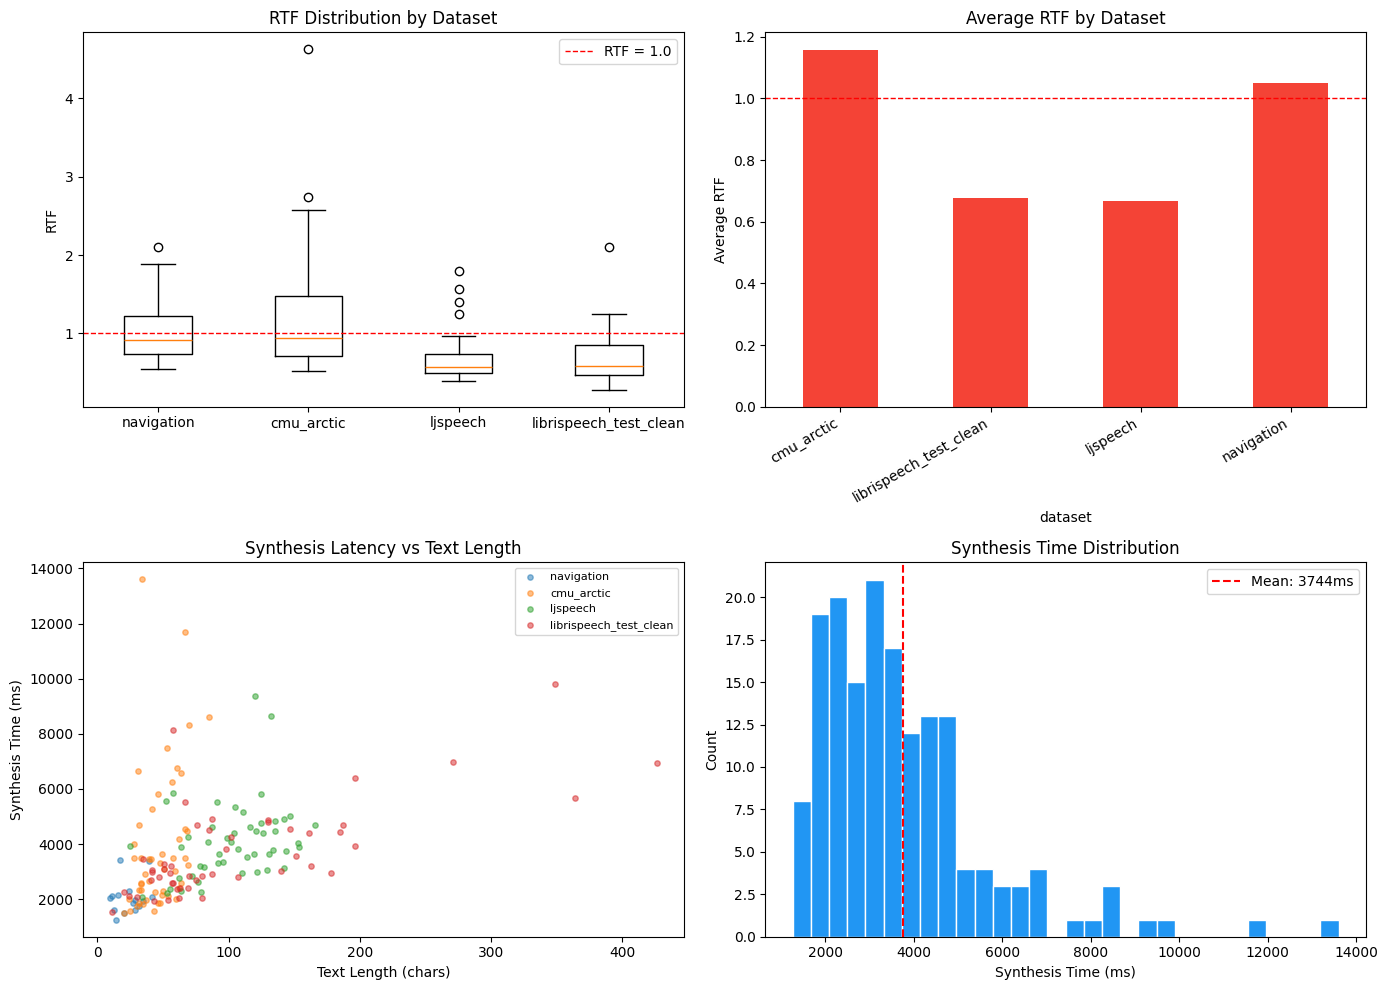

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) RTF by dataset (box plot)
ax = axes[0, 0]
datasets_present = df["dataset"].unique()
box_data = [df[df["dataset"] == d]["rtf"].dropna() for d in datasets_present]
ax.boxplot(box_data, labels=datasets_present)
ax.axhline(1.0, linestyle="--", color="red", linewidth=1, label="RTF = 1.0")
ax.set_ylabel("RTF")
ax.set_title("RTF Distribution by Dataset")
ax.legend()

# 2) RTF by dataset (bar — average)
ax = axes[0, 1]
avg_by_ds = df.groupby("dataset")["rtf"].mean()
colors = ["#4CAF50" if v < 0.3 else "#FF9800" if v < 0.5 else "#F44336" for v in avg_by_ds]
avg_by_ds.plot(kind="bar", ax=ax, color=colors)
ax.axhline(1.0, linestyle="--", color="red", linewidth=1)
ax.set_ylabel("Average RTF")
ax.set_title("Average RTF by Dataset")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

# 3) Latency vs text length (scatter)
ax = axes[1, 0]
for dname in datasets_present:
    subset = df[df["dataset"] == dname]
    ax.scatter(subset["char_len"], subset["synth_ms"], alpha=0.5, s=15, label=dname)
ax.set_xlabel("Text Length (chars)")
ax.set_ylabel("Synthesis Time (ms)")
ax.set_title("Synthesis Latency vs Text Length")
ax.legend(fontsize=8)

# 4) Synthesis time histogram
ax = axes[1, 1]
ax.hist(df["synth_ms"].dropna(), bins=30, color="#2196F3", edgecolor="white")
ax.axvline(df["synth_ms"].mean(), color="red", linestyle="--", label=f"Mean: {df['synth_ms'].mean():.0f}ms")
ax.set_xlabel("Synthesis Time (ms)")
ax.set_ylabel("Count")
ax.set_title("Synthesis Time Distribution")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save TTS RTF Analysis chart for report
figures_dir = ROOT / "reports" / "submission_pack_2026-04-15"
figures_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(figures_dir / "tts_rtf_analysis.png", dpi=150, bbox_inches='tight')
print(f"✅ Saved chart: {(figures_dir / 'tts_rtf_analysis.png').relative_to(ROOT)}")

## Save Results

In [81]:
results_dir = ROOT / "results" / "tts_eval"
results_dir.mkdir(parents=True, exist_ok=True)

ts = time.strftime("%Y%m%d_%H%M%S")

# Full results
df.to_csv(results_dir / f"tts_bench_{ts}_full.csv", index=False)

# Summary
summary.to_csv(results_dir / f"tts_bench_{ts}_summary.csv")

print(f"✅ Results saved to {results_dir.relative_to(ROOT)}/")
print(f"   Full:    tts_bench_{ts}_full.csv")
print(f"   Summary: tts_bench_{ts}_summary.csv")

✅ Results saved to results\tts_eval/
   Full:    tts_bench_20260416_102333_full.csv
   Summary: tts_bench_20260416_102333_summary.csv
